In [1]:
import re, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

ROOT  = Path('/mnt/intelpa-1/armin/containers/storage/main/microgs')
LOGS  = ROOT / 'logs'
CKPTS = ROOT / 'checkpoints'
sys.path.insert(0, str(ROOT))

## 1 · Define variants and parse training logs

In [16]:
# Ablation variants: full model + 3 component ablations
VARIANTS = [
    dict(run='full_model',   ckpt='gmf_refined_best.pt',          densify=True,  swc_init=True,  grad_w=0.3, log_dir=LOGS),
    dict(run='no_densify',   ckpt='ablation_no_densify_best.pt',   densify=False, swc_init=True,  grad_w=0.3, log_dir=LOGS/'ablation_no_densify'),
    dict(run='no_swc',       ckpt='ablation_no_swc_best.pt',       densify=True,  swc_init=False, grad_w=0.3, log_dir=LOGS/'ablation_no_swc'),
    dict(run='no_grad_loss', ckpt='ablation_no_grad_loss_best.pt', densify=True,  swc_init=True,  grad_w=0.0, log_dir=LOGS/'ablation_no_grad_loss'),
]

_PSNR_RE  = re.compile(r'PSNR@(\d+).*?:\s*([\d.]+)\s*dB')
_K_RE     = re.compile(r'Step\s+\d+:\s+K=(\d+)')
_BEST_RE  = re.compile(r'New best PSNR:\s*([\d.]+)\s*dB')
_STOP_RE  = re.compile(r'Early stopping triggered at step\s+(\d+).*best PSNR:\s*([\d.]+)\s*dB')

def _parse_log(log_path):
    """Return (steps, psnrs, final_K, best_psnr, stopped_at) from one log file."""
    txt    = log_path.read_text(errors='replace')
    steps  = [int(m.group(1)) for m in _PSNR_RE.finditer(txt)]
    psnrs  = [float(m.group(2)) for m in _PSNR_RE.finditer(txt)]
    ks     = [int(m.group(1)) for m in _K_RE.finditer(txt)]
    final_K    = ks[-1]   if ks   else None
    best_psnr  = max([float(m.group(1)) for m in _BEST_RE.finditer(txt)], default=None)
    stop_match = list(_STOP_RE.finditer(txt))
    stopped_at = int(stop_match[-1].group(1)) if stop_match else (steps[-1] if steps else None)
    return steps, psnrs, final_K, best_psnr, stopped_at

def _find_log_for_ckpt(log_dir, ckpt_name):
    """Pick the log that most recently saved <ckpt_name>."""
    candidates = []
    for p in sorted(log_dir.glob('training_*.log')):
        if ckpt_name in p.read_text(errors='replace'):
            candidates.append(p)
    if candidates:
        return candidates[-1]
    logs = sorted(log_dir.glob('training_*.log'))
    return logs[-1] if logs else None

records = []
for v in VARIANTS:
    log_path = _find_log_for_ckpt(v['log_dir'], v['ckpt'])
    if log_path is None:
        print(f"{v['run']}: no log found in {v['log_dir']}")
        continue
    steps, psnrs, final_K, best_psnr, stopped_at = _parse_log(log_path)
    records.append({
        'run':        v['run'],
        'densify':    v['densify'],
        'swc_init':   v['swc_init'],
        'grad_w':     v['grad_w'],
        'ckpt':       v['ckpt'],
        'log':        log_path.name,
        'final_K':    final_K,
        'best_psnr':  best_psnr,
        'stopped_at': stopped_at,
    })
    print(f"{v['run']:20s}  log={log_path.name}  K={final_K}  best_PSNR={best_psnr:.2f} dB  stopped@{stopped_at}")

df = pd.DataFrame(records)
display(df[['run','densify','swc_init','grad_w','final_K','best_psnr','stopped_at','log']]
        .rename(columns={'best_psnr':'PSNR (dB)','stopped_at':'steps','final_K':'K_final','grad_w':'w_grad'})
        .to_string(index=False))

full_model            log=training_20260417_144204.log  K=100000  best_PSNR=38.86 dB  stopped@95500
no_densify            log=training_20260402_124421.log  K=10000  best_PSNR=37.21 dB  stopped@19000
no_swc                log=training_20260402_125211.log  K=3984  best_PSNR=37.41 dB  stopped@32000
no_grad_loss          log=training_20260402_125946.log  K=6920  best_PSNR=37.47 dB  stopped@30000


'         run  densify  swc_init  w_grad  K_final  PSNR (dB)  steps                          log\n  full_model     True      True     0.3   100000      38.86  95500 training_20260417_144204.log\n  no_densify    False      True     0.3    10000      37.21  19000 training_20260402_124421.log\n      no_swc     True     False     0.3     3984      37.41  32000 training_20260402_125211.log\nno_grad_loss     True      True     0.0     6920      37.47  30000 training_20260402_125946.log'

## 2 · Load PSNR training curves

In [17]:
curves = {}  # run_name → (steps_array, psnr_array)
for v in VARIANTS:
    log_path = _find_log_for_ckpt(v['log_dir'], v['ckpt'])
    if log_path is None:
        continue
    steps, psnrs, *_ = _parse_log(log_path)
    if steps:
        curves[v['run']] = (np.array(steps), np.array(psnrs))
        print(f"{v['run']:20s}: {len(steps):4d} eval points  "
              f"steps [{steps[0]}, {steps[-1]}]  final PSNR {psnrs[-1]:.2f} dB")

full_model          :  191 eval points  steps [500, 95500]  final PSNR 38.76 dB
no_densify          :   38 eval points  steps [500, 19000]  final PSNR 37.20 dB
no_swc              :   64 eval points  steps [500, 32000]  final PSNR 37.39 dB
no_grad_loss        :   60 eval points  steps [500, 30000]  final PSNR 37.33 dB


## 3 · Densification ablation

Densification grows the Gaussian count from K=10 000 during the first 20 000 steps by  
splitting high-gradient Gaussians. Without densification the Gaussian budget is fixed at K=10 000.

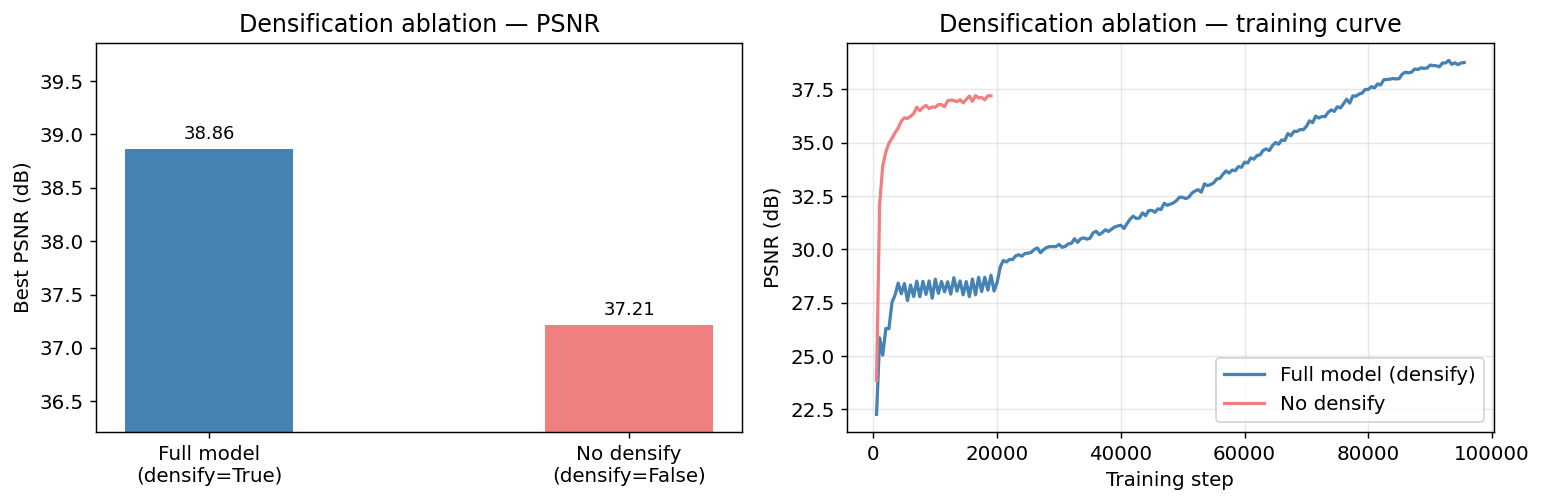

In [18]:
(LOGS / 'ablation').mkdir(exist_ok=True)

densify_rows = df[df['run'].isin(['full_model', 'no_densify'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
labels = ['Full model\n(densify=True)', 'No densify\n(densify=False)']
vals   = [densify_rows.loc[densify_rows.run == r, 'best_psnr'].values[0]
          for r in ['full_model', 'no_densify']]
bars = ax.bar(labels, vals, color=['steelblue', 'lightcoral'], width=0.4)
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Densification ablation — PSNR')
ax.set_ylim(min(vals) - 1.0, max(vals) + 1.0)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
colors = {'full_model': 'steelblue', 'no_densify': 'lightcoral'}
for name, label in [('full_model', 'Full model (densify)'), ('no_densify', 'No densify')]:
    if name in curves:
        s, p = curves[name]
        ax.plot(s, p, color=colors[name], label=label, linewidth=1.8)
ax.set_xlabel('Training step'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Densification ablation — training curve')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'densify_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 4 · SWC initialization ablation

`swc_init=True` seeds Gaussian means along the neuron skeleton (SWC morphology, 1034 nodes + edge-interpolated  
points to reach K=10 000). `swc_init=False` uses random Gaussian initialisation inside the unit cube.

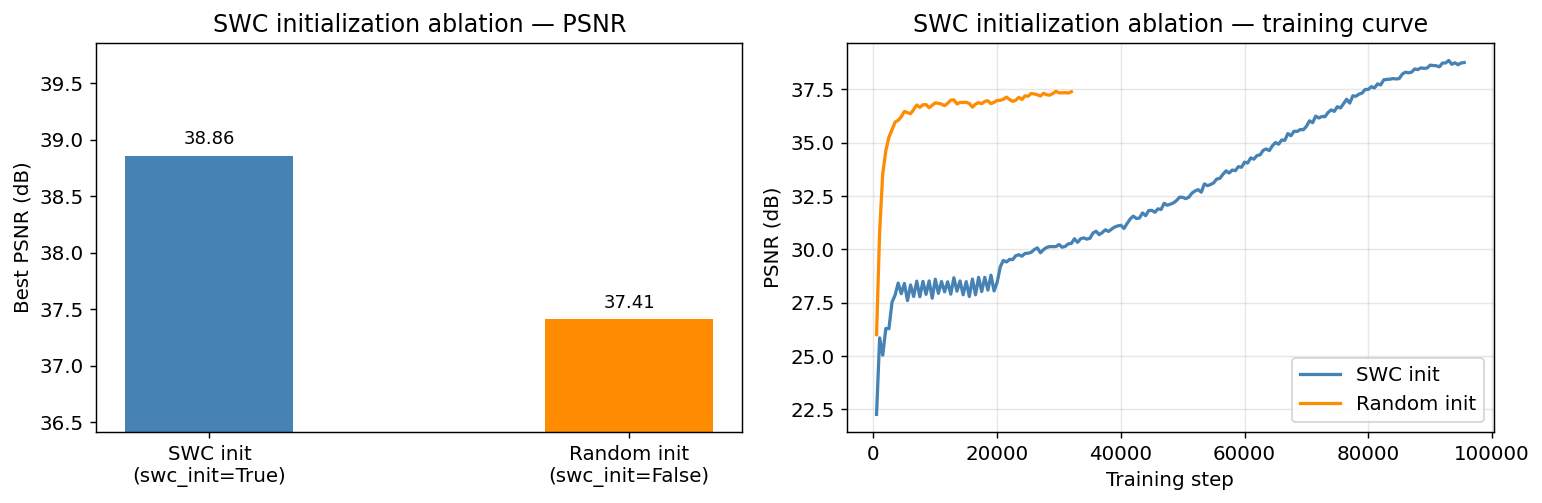

In [19]:
swc_rows = df[df['run'].isin(['full_model', 'no_swc'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
labels = ['SWC init\n(swc_init=True)', 'Random init\n(swc_init=False)']
vals   = [swc_rows.loc[swc_rows.run == r, 'best_psnr'].values[0]
          for r in ['full_model', 'no_swc']]
bars = ax.bar(labels, vals, color=['steelblue', 'darkorange'], width=0.4)
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('SWC initialization ablation — PSNR')
ax.set_ylim(min(vals) - 1.0, max(vals) + 1.0)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
colors = {'full_model': 'steelblue', 'no_swc': 'darkorange'}
for name, label in [('full_model', 'SWC init'), ('no_swc', 'Random init')]:
    if name in curves:
        s, p = curves[name]
        ax.plot(s, p, color=colors[name], label=label, linewidth=1.8)
ax.set_xlabel('Training step'); ax.set_ylabel('PSNR (dB)')
ax.set_title('SWC initialization ablation — training curve')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'swc_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 5 · Gradient-loss weight ablation

The gradient loss penalises the L2 norm of the predicted intensity gradient, encouraging smooth spatial  
transitions. `grad_w=0.3` is the default; `grad_w=0.0` disables it entirely.

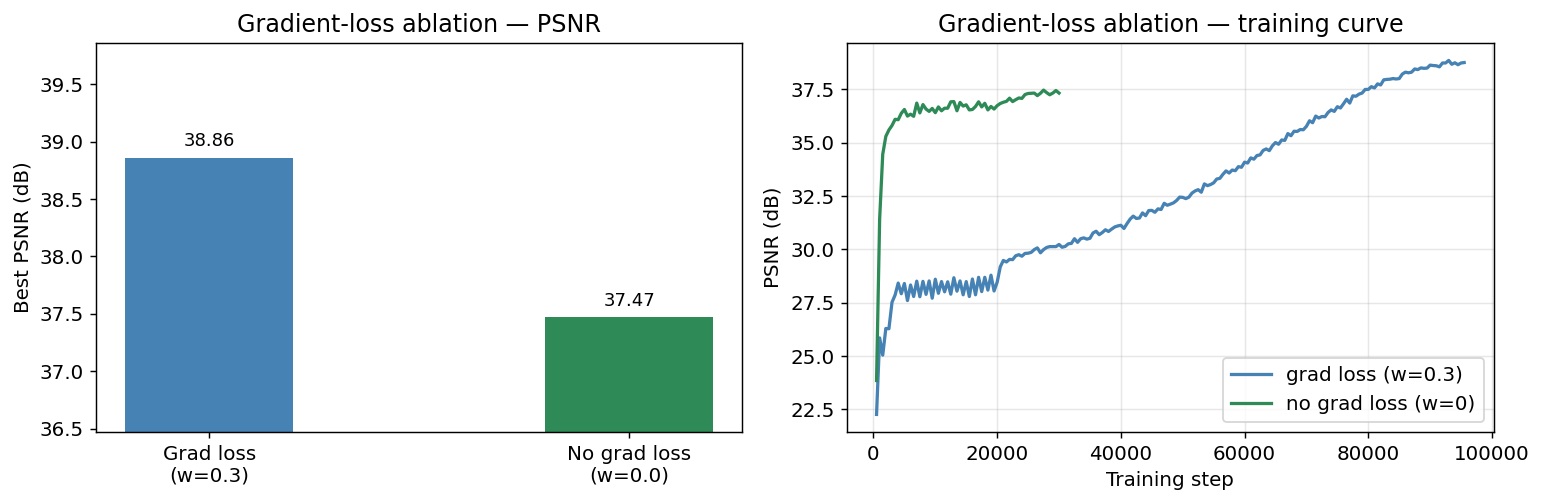

In [20]:
grad_rows = df[df['run'].isin(['full_model', 'no_grad_loss'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
labels = ['Grad loss\n(w=0.3)', 'No grad loss\n(w=0.0)']
vals   = [grad_rows.loc[grad_rows.run == r, 'best_psnr'].values[0]
          for r in ['full_model', 'no_grad_loss']]
bars = ax.bar(labels, vals, color=['steelblue', 'seagreen'], width=0.4)
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Gradient-loss ablation — PSNR')
ax.set_ylim(min(vals) - 1.0, max(vals) + 1.0)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
colors = {'full_model': 'steelblue', 'no_grad_loss': 'seagreen'}
for name, label in [('full_model', 'grad loss (w=0.3)'), ('no_grad_loss', 'no grad loss (w=0)')]:
    if name in curves:
        s, p = curves[name]
        ax.plot(s, p, color=colors[name], label=label, linewidth=1.8)
ax.set_xlabel('Training step'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Gradient-loss ablation — training curve')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'gradloss_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 6 · Component ablation summary — PSNR vs steps

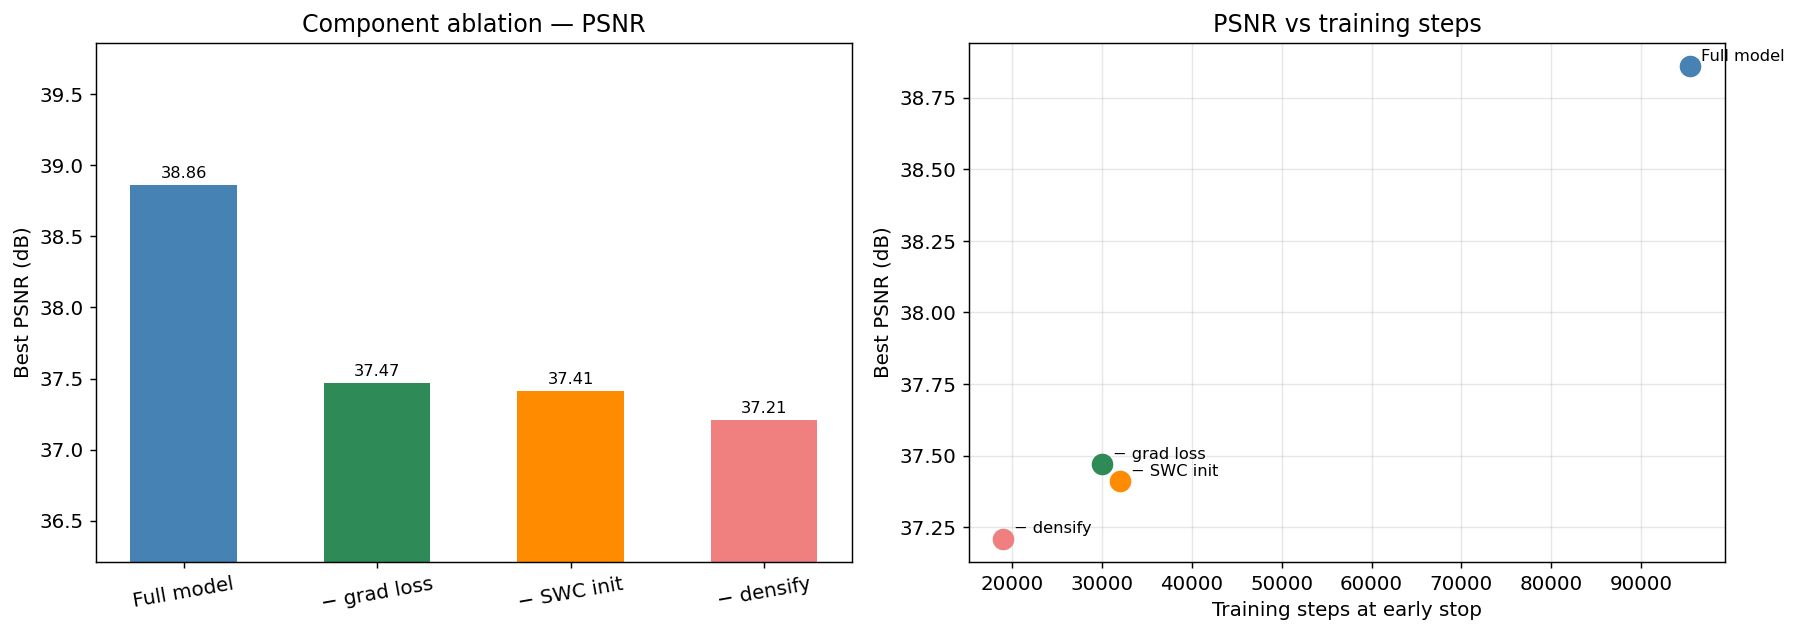

In [21]:
COLORS = {
    'full_model':   'steelblue',
    'no_densify':   'lightcoral',
    'no_swc':       'darkorange',
    'no_grad_loss': 'seagreen',
}
LABELS = {
    'full_model':   'Full model',
    'no_densify':   '− densify',
    'no_swc':       '− SWC init',
    'no_grad_loss': '− grad loss',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PSNR bar chart for all variants
ax = axes[0]
ordered = df.sort_values('best_psnr', ascending=False).reset_index(drop=True)
bars = ax.bar(
    [LABELS.get(r, r) for r in ordered['run']],
    ordered['best_psnr'],
    color=[COLORS.get(r, 'gray') for r in ordered['run']],
    width=0.55,
)
pad = (ordered['best_psnr'].max() - ordered['best_psnr'].min()) * 0.03 + 0.05
ax.set_ylim(ordered['best_psnr'].min() - 1.0, ordered['best_psnr'].max() + 1.0)
for bar, v in zip(bars, ordered['best_psnr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pad * 0.5,
            f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Component ablation — PSNR')
ax.tick_params(axis='x', rotation=10)

# Right: PSNR vs steps (training efficiency)
ax = axes[1]
for _, row in df.iterrows():
    ax.scatter(row['stopped_at'], row['best_psnr'],
               s=120, color=COLORS.get(row['run'], 'gray'), zorder=3)
    ax.annotate(LABELS.get(row['run'], row['run']),
                (row['stopped_at'], row['best_psnr']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.set_xlabel('Training steps at early stop'); ax.set_ylabel('Best PSNR (dB)')
ax.set_title('PSNR vs training steps')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'component_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 7 · All training curves

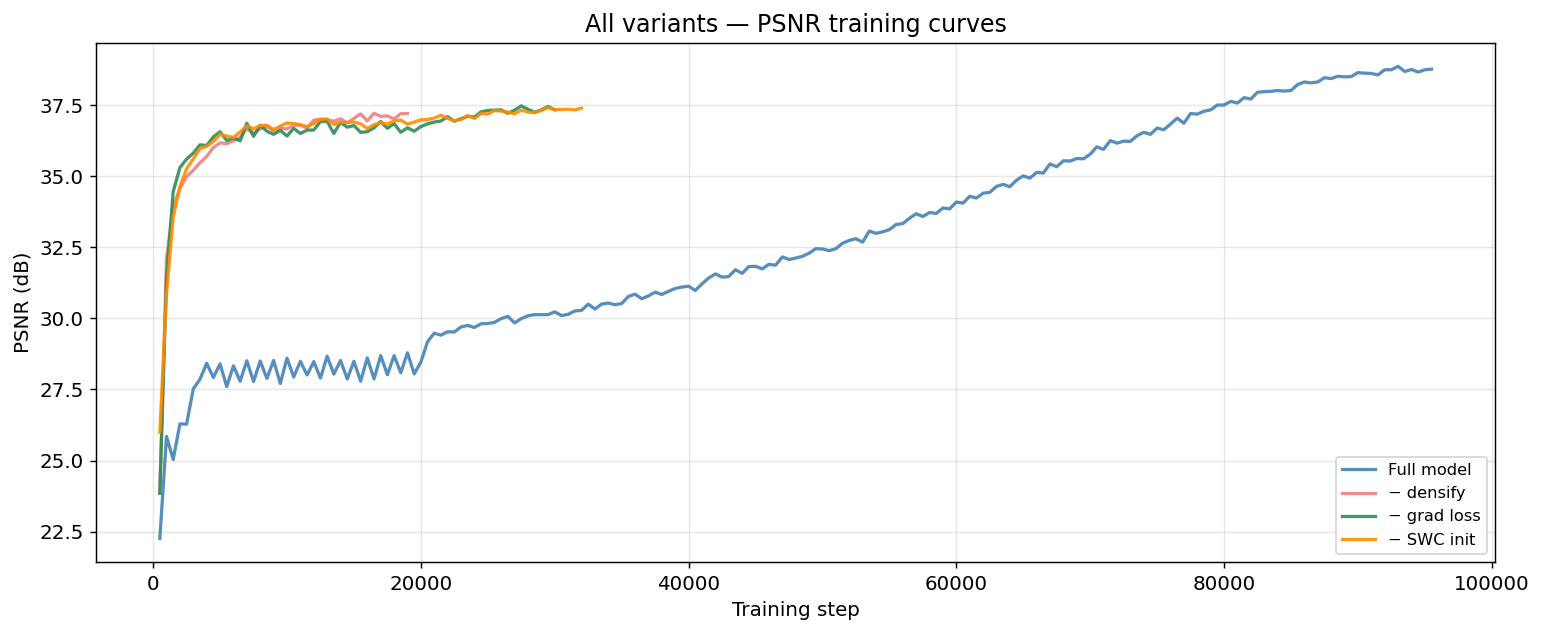

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (s, p) in sorted(curves.items()):
    ax.plot(s, p, label=LABELS.get(name, name), color=COLORS.get(name, 'gray'),
            linewidth=1.8, alpha=0.9)
ax.set_xlabel('Training step'); ax.set_ylabel('PSNR (dB)')
ax.set_title('All variants — PSNR training curves')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'all_curves.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 7b · Summary table + export CSV

In [23]:
has_metrics = ('ssim' in df.columns) and df['ssim'].notna().any()

cols = ['run', 'densify', 'swc_init', 'grad_w', 'final_K', 'best_psnr', 'stopped_at']
renames = {'best_psnr': 'PSNR (dB)', 'stopped_at': 'steps', 'final_K': 'K_final',
           'grad_w': 'w_grad', 'swc_init': 'SWC', 'densify': 'densify'}

if has_metrics:
    cols = cols[:6] + ['ssim', 'lpips'] + cols[6:]
    renames.update({'ssim': 'SSIM ↑', 'lpips': 'LPIPS ↓'})

summary = df[cols].copy()
summary['best_psnr'] = summary['best_psnr'].round(2)
if has_metrics:
    summary['ssim']  = summary['ssim'].map(lambda v: f'{v:.4f}' if pd.notna(v) else 'N/A')
    summary['lpips'] = summary['lpips'].map(lambda v: f'{v:.4f}' if pd.notna(v) else 'N/A')
summary = summary.rename(columns=renames)
summary.to_csv(LOGS / 'ablation' / 'results.csv', index=False)
print('Saved → logs/ablation/results.csv')
display(summary)

Saved → logs/ablation/results.csv


,run,densify,SWC,w_grad,K_final,PSNR (dB),steps
0,full_model,True,True,0.3,100000,38.86,95500
1,no_densify,False,True,0.3,10000,37.21,19000
2,no_swc,True,False,0.3,3984,37.41,32000
3,no_grad_loss,True,True,0.0,6920,37.47,30000


## 8 · Setup — model loader, volume, helpers

In [25]:
import torch
import torch.nn.functional as F
import tifffile
from skimage.metrics import structural_similarity
import lpips as lpips_lib

from src.model import GaussianMixtureField
from src.utils import load_config

TIF_PATH    = ROOT / 'src' / 'data' / 'raw' / '10-2900-control-cell-05_cropped_corrected.tif'
INFER_BATCH = 2 ** 18          # keep memory reasonable for large volumes
SLICE_IDXS  = [10, 25, 50, 75]
LPIPS_SZ    = 256
N_LPIPS_SLICES = 20

vol_raw = tifffile.imread(str(TIF_PATH)).astype('float32')
vmin_v, vmax_v = vol_raw.min(), vol_raw.max()
gt_vol  = (vol_raw - vmin_v) / (vmax_v - vmin_v)
D, H, W = gt_vol.shape
slice_idxs = [max(0, min(D-1, z)) for z in SLICE_IDXS]

# Build a flat grid of normalised [-1, 1] 3D coordinates
axes_g   = [np.linspace(-1, 1, s, dtype='float32') for s in (D, H, W)]
coords_t = torch.from_numpy(
    np.stack([g.ravel() for g in np.meshgrid(*axes_g, indexing='ij')], axis=-1)
)

lpips_fn = lpips_lib.LPIPS(net='alex').cuda()
lpips_fn.eval()

cfg = load_config(str(ROOT / 'config.yml'))

def load_gmf_model(ckpt_name):
    ckpt_path = CKPTS / ckpt_name
    if not ckpt_path.exists():
        print(f'  checkpoint not found: {ckpt_path}')
        return None
    state = torch.load(ckpt_path, weights_only=True, map_location='cpu')
    K = state['means'].shape[0]
    model = GaussianMixtureField(
        num_gaussians=K,
        init_scale=cfg['model']['init_scale'],
        init_amplitude=cfg['model']['init_amplitude'],
        bounds=cfg['model']['bounds'],
    )
    model.load_state_dict(state, strict=False)
    print(f'  loaded {ckpt_name}  K={K:,}')
    return model.cuda()

def reconstruct(model):
    model.eval()
    # cap batch so N*K*20 bytes fits in ~40% of free VRAM
    free_bytes, _ = torch.cuda.mem_get_info()
    K = model.num_gaussians
    batch = max(256, min(INFER_BATCH, int(free_bytes * 0.40 / (K * 20))))
    parts = []
    with torch.no_grad():
        for i in range(0, len(coords_t), batch):
            parts.append(model(coords_t[i:i+batch].cuda()).squeeze(-1).cpu())
    return torch.cat(parts).numpy().reshape(D, H, W)

def slice_metrics(gt_sl, rc_sl):
    ssim_val = structural_similarity(gt_sl, rc_sl, data_range=1.0)
    gt_t = torch.from_numpy(gt_sl)[None, None].expand(1, 3, -1, -1)
    rc_t = torch.from_numpy(rc_sl)[None, None].expand(1, 3, -1, -1)
    gt_t = F.interpolate(gt_t, LPIPS_SZ, mode='bilinear', align_corners=False)
    rc_t = F.interpolate(rc_t, LPIPS_SZ, mode='bilinear', align_corners=False)
    with torch.no_grad():
        lp_val = lpips_fn(gt_t.cuda()*2-1, rc_t.cuda()*2-1).item()
    return ssim_val, lp_val

print(f'Volume {D}x{H}x{W}   slices at z={slice_idxs}')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth
Volume 100x647x813   slices at z=[10, 25, 50, 75]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

## 9 · SSIM & LPIPS

In [26]:
metrics_rows = []
for v in VARIANTS:
    metrics_path = LOGS / v['log_dir'].name / 'metrics.json' if v['log_dir'] != LOGS else LOGS / 'metrics_full.json'
    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        print(f"{v['run']:20s}: cached   SSIM={m['ssim']:.4f}  LPIPS={m['lpips']:.4f}")
        metrics_rows.append({'run': v['run'], **m})
        continue

    model = load_gmf_model(v['ckpt'])
    if model is None:
        print(f"{v['run']:20s}: no checkpoint — skipping")
        continue

    recon = reconstruct(model)
    torch.cuda.empty_cache()

    ssim_val = float(np.mean([
        structural_similarity(gt_vol[z], recon[z], data_range=1.0)
        for z in range(D)
    ]))

    z_idxs  = np.linspace(0, D - 1, N_LPIPS_SLICES, dtype=int)
    lp_vals = []
    for z in z_idxs:
        gt_t = torch.from_numpy(gt_vol[z])[None, None].expand(1, 3, -1, -1)
        rc_t = torch.from_numpy(recon[z])[None, None].expand(1, 3, -1, -1)
        gt_t = F.interpolate(gt_t, LPIPS_SZ, mode='bilinear', align_corners=False)
        rc_t = F.interpolate(rc_t, LPIPS_SZ, mode='bilinear', align_corners=False)
        with torch.no_grad():
            lp_vals.append(lpips_fn(gt_t.cuda()*2-1, rc_t.cuda()*2-1).item())
    lpips_val = float(np.mean(lp_vals))

    m = {'ssim': ssim_val, 'lpips': lpips_val}
    metrics_path.parent.mkdir(exist_ok=True)
    metrics_path.write_text(json.dumps(m, indent=2))
    print(f"{v['run']:20s}: computed  SSIM={ssim_val:.4f}  LPIPS={lpips_val:.4f}  → saved")
    metrics_rows.append({'run': v['run'], **m})
    del recon

mdf = pd.DataFrame(metrics_rows)
for col in ('ssim', 'lpips'):
    df[col] = df['run'].map(mdf.set_index('run')[col])

  loaded gmf_refined_best.pt  K=100,000
✗ CUDA kernel skipped (memory): N=262144, K=100000, need=524.29GB, avail=24.75GB
⚠ Using smaller fallback k_chunk=735 (requested 1024, N=262144, free+reusable=24.69GB)


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, ascending in [
    (axes[0], 'ssim',  'SSIM ↑ (higher is better)', False),
    (axes[1], 'lpips', 'LPIPS ↓ (lower is better)', True),
]:
    vals = df[col].dropna()
    if vals.empty:
        ax.set_title(f'{col.upper()} — no data'); continue
    ordered = df.sort_values(col, ascending=ascending).reset_index(drop=True)
    bar_colors = [COLORS.get(r, 'gray') for r in ordered['run']]
    bar_labels = [LABELS.get(r, r) for r in ordered['run']]
    bars = ax.bar(bar_labels, ordered[col], color=bar_colors, width=0.55)
    ax.set_ylabel(label)
    ax.set_title(f'{col.upper()} by variant')
    ax.tick_params(axis='x', rotation=10)
    pad = (ordered[col].max() - ordered[col].min()) * 0.03 + 1e-6
    ax.set_ylim(ordered[col].min() - pad, ordered[col].max() + pad * 4)
    for bar, v in zip(bars, ordered[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pad * 0.3,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perceptual quality metrics  (SSIM: all slices · LPIPS: AlexNet, 20 slices @ 256 px)',
             fontsize=11)
plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'ssim_lpips.pdf', dpi=600, bbox_inches='tight')
plt.show()
print('Saved → logs/ablation/ssim_lpips.pdf')

## 10 · Volume reconstruction — GT / Recon / Diff  (slices at z=10 · 25 · 50 · 75)

In [ ]:
for v in VARIANTS:
    print(f"Processing {v['run']}...")
    model = load_gmf_model(v['ckpt'])
    if model is None:
        print('  no checkpoint, skipping')
        continue

    recon = reconstruct(model)
    diff  = np.abs(recon - gt_vol)
    psnr_full = float(-10 * np.log10(((recon - gt_vol)**2).mean() + 1e-8))

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.subplots_adjust(top=0.91, right=0.88, hspace=0.30, wspace=0.03)

    run_row = df[df.run == v['run']]
    K_final  = int(run_row['final_K'].values[0]) if not run_row.empty and pd.notna(run_row['final_K'].values[0]) else None
    K_final_s = f'{K_final:,}' if K_final is not None else '?'
    ssim_s   = f"{float(run_row['ssim'].values[0]):.4f}"  if not run_row.empty and 'ssim'  in run_row and pd.notna(run_row['ssim'].values[0])  else 'N/A'
    lpips_s  = f"{float(run_row['lpips'].values[0]):.4f}" if not run_row.empty and 'lpips' in run_row and pd.notna(run_row['lpips'].values[0]) else 'N/A'

    fig.suptitle(
        f"{LABELS.get(v['run'], v['run'])}  │  "
        f"densify={v['densify']}  SWC={v['swc_init']}  w_grad={v['grad_w']}  │  K_final={K_final_s}\n"
        f"PSNR {psnr_full:.2f} dB  │  SSIM {ssim_s}  │  LPIPS {lpips_s}",
        fontsize=10, fontweight='bold'
    )

    gr_min   = min(gt_vol.min(), recon.min())
    gr_max   = max(gt_vol.max(), recon.max())
    diff_max = diff.max() + 1e-8

    for col, z in enumerate(slice_idxs):
        axes[0, col].imshow(gt_vol[z], cmap='gray', vmin=gr_min, vmax=gr_max)
        axes[0, col].set_title(f'GT  z={z}', fontsize=9)
        axes[1, col].imshow(recon[z], cmap='gray', vmin=gr_min, vmax=gr_max)
        axes[1, col].set_title(f'Recon  z={z}', fontsize=9)
        im = axes[2, col].imshow(diff[z] / diff_max, cmap='hot', vmin=0, vmax=1)
        s, lp = slice_metrics(gt_vol[z], recon[z])
        axes[2, col].set_title(f'|Diff|  z={z}\nSSIM {s:.3f}  LPIPS {lp:.3f}', fontsize=8)

    for ax in axes.flat:
        ax.axis('off')

    fig.canvas.draw()
    p0 = axes[2, 0].get_position(); p1 = axes[2, -1].get_position()
    cbar_ax = fig.add_axes([p1.x1 + 0.01, p0.y0, 0.015, p0.y1 - p0.y0])
    fig.colorbar(im, cax=cbar_ax, label=f'|error|  (max={diff_max:.4f})')

    out = LOGS / 'ablation' / f"recon_{v['run']}.pdf"
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {out}')
    torch.cuda.empty_cache()

## 11 · Maximum Intensity Projection (MIP) — XY · XZ · ZY

In [ ]:
def pad_square(img, size=1024, fill=0.0):
    h, w = img.shape
    out  = np.full((size, size), fill, dtype=np.float32)
    y0   = (size - h) // 2; x0 = (size - w) // 2
    out[y0:y0+h, x0:x0+w] = img
    return out

for v in VARIANTS:
    model = load_gmf_model(v['ckpt'])
    if model is None:
        print(f"{v['run']}: no checkpoint, skipping")
        continue

    recon     = reconstruct(model)
    psnr_full = float(-10 * np.log10(((recon - gt_vol)**2).mean() + 1e-8))

    views = [
        ('XY', 'X', 'Y', np.max(gt_vol, axis=0), np.max(recon, axis=0)),
        ('XZ', 'X', 'Z', np.max(gt_vol, axis=1), np.max(recon, axis=1)),
        ('ZY', 'Y', 'Z', np.max(gt_vol, axis=2), np.max(recon, axis=2)),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(13, 9))
    fig.subplots_adjust(top=0.91, right=0.88, hspace=0.35, wspace=0.08)

    run_row = df[df.run == v['run']]
    K_final  = int(run_row['final_K'].values[0]) if not run_row.empty and pd.notna(run_row['final_K'].values[0]) else None
    K_final_s = f'{K_final:,}' if K_final is not None else '?'
    ssim_s   = f"{float(run_row['ssim'].values[0]):.4f}"  if not run_row.empty and 'ssim'  in run_row and pd.notna(run_row['ssim'].values[0])  else 'N/A'
    lpips_s  = f"{float(run_row['lpips'].values[0]):.4f}" if not run_row.empty and 'lpips' in run_row and pd.notna(run_row['lpips'].values[0]) else 'N/A'

    fig.suptitle(
        f"{LABELS.get(v['run'], v['run'])}  │  "
        f"densify={v['densify']}  SWC={v['swc_init']}  w_grad={v['grad_w']}  │  K_final={K_final_s}\n"
        f"PSNR {psnr_full:.2f} dB  │  SSIM {ssim_s}  │  LPIPS {lpips_s}",
        fontsize=10, fontweight='bold'
    )

    vmin = min(gt_vol.min(), recon.min())
    vmax = max(gt_vol.max(), recon.max())

    for col, (label, xlabel, ylabel, gt_mip, rc_mip) in enumerate(views):
        diff_mip = np.abs(gt_mip - rc_mip)
        diff_max = diff_mip.max() + 1e-8
        gt_sq    = pad_square(gt_mip)
        rc_sq    = pad_square(rc_mip)
        diff_sq  = pad_square(diff_mip / diff_max)

        for row_idx, (img, cmap, vlo, vhi, title) in enumerate([
            (gt_sq,   'gray', vmin, vmax, f'GT  {label}'),
            (rc_sq,   'gray', vmin, vmax, f'Recon  {label}'),
            (diff_sq, 'hot',  0,    1,    f'|Diff|  {label}'),
        ]):
            ax = axes[row_idx, col]
            im_obj = ax.imshow(img, cmap=cmap, vmin=vlo, vmax=vhi,
                               aspect='equal', interpolation='nearest')
            ax.set_title(title, fontsize=9)
            ax.set_xlabel(xlabel, fontsize=8, labelpad=2)
            ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            if row_idx == 2:
                im = im_obj

    fig.canvas.draw()
    p0 = axes[2, 0].get_position(); p1 = axes[2, -1].get_position()
    cbar_ax = fig.add_axes([p1.x1 + 0.01, p0.y0, 0.015, p0.y1 - p0.y0])
    fig.colorbar(im, cax=cbar_ax, label='|error|  (normalised per view)')

    out = LOGS / 'ablation' / f"mip_{v['run']}.pdf"
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')
    torch.cuda.empty_cache()